# SupportPilot AI — Model 2: TF-IDF + Linear SVM

## Tujuan

Notebook ini digunakan untuk membangun model kedua untuk
Intent Classification menggunakan:

- TF-IDF sebagai text feature extraction
- Linear Support Vector Machine (Linear SVM) sebagai classifier

Konfigurasi TF-IDF dibuat sama dengan baseline Logistic Regression
agar perbandingan antar-model tetap adil.

Model dilatih menggunakan Training Set dan dievaluasi menggunakan
Validation Set.

Test Set belum digunakan pada tahap ini.

Evaluasi mencakup:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Weighted F1-score
- Classification Report
- Confusion Analysis
- Error Analysis
- Decision Margin Analysis
- Training Time
- Inference Time

Hasil akan dibandingkan dengan baseline TF-IDF + Logistic Regression.

In [1]:
# import library
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [2]:
# path
TRAIN_PATH = Path(
    "../data/processed/train.csv"
)

VALIDATION_PATH = Path(
    "../data/processed/validation.csv"
)

MODEL_DIR = Path(
    "../models"
)

REPORT_DIR = Path(
    "../reports/metrics"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [3]:
# validasi file
required_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {file_path}"
        )

print("Semua dataset ditemukan.")

Semua dataset ditemukan.


In [4]:
# load dataset
train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(validation_df):,}"
)

Train      : 35,861
Validation : 4,483


In [5]:
# feature and target
FEATURE_COLUMN = "instruction"
TARGET_COLUMN = "intent"

X_train = train_df[
    FEATURE_COLUMN
]

y_train = train_df[
    TARGET_COLUMN
]

X_validation = validation_df[
    FEATURE_COLUMN
]

y_validation = validation_df[
    TARGET_COLUMN
]

print(
    f"X_train       : {X_train.shape}"
)

print(
    f"X_validation  : {X_validation.shape}"
)

print(
    f"Jumlah intent : {y_train.nunique()}"
)

X_train       : (35861,)
X_validation  : (4483,)
Jumlah intent : 46


In [6]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

In [7]:
# buat linear SVM 
linear_svm = LinearSVC(
    C=1.0,
    loss="squared_hinge",
    dual="auto",
    max_iter=5000,
)

In [8]:
model = Pipeline(
    steps=[
        (
            "tfidf",
            tfidf_vectorizer,
        ),
        (
            "classifier",
            linear_svm,
        ),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'st

In [9]:
# training
start_train = time.perf_counter()

model.fit(
    X_train,
    y_train,
)

training_time = (
    time.perf_counter()
    - start_train
)

print(
    f"Training selesai dalam "
    f"{training_time:.2f} detik."
)

Training selesai dalam 12.27 detik.


In [10]:
# vocabulary size
tfidf_fitted = (
    model.named_steps["tfidf"]
)

vocabulary_size = len(
    tfidf_fitted.vocabulary_
)

print(
    f"Jumlah TF-IDF features: "
    f"{vocabulary_size:,}"
)

Jumlah TF-IDF features: 9,038


In [11]:
# predict validation
start_inference = time.perf_counter()

validation_predictions = model.predict(
    X_validation
)

inference_time = (
    time.perf_counter()
    - start_inference
)

average_inference_ms = (
    inference_time
    / len(X_validation)
    * 1000
)

print(
    f"Total inference time : "
    f"{inference_time:.4f} detik"
)

print(
    f"Rata-rata per sample : "
    f"{average_inference_ms:.4f} ms"
)

Total inference time : 0.2352 detik
Rata-rata per sample : 0.0525 ms


In [12]:
# metrics
accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

macro_precision = precision_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0,
)

In [13]:
metrics_summary = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1",
        ],
        "score": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
    }
)

metrics_summary["score"] = (
    metrics_summary["score"]
    .round(4)
)

metrics_summary

,metric,score
0,Accuracy,0.9873
1,Macro Precision,0.9877
2,Macro Recall,0.9875
3,Macro F1,0.9874
4,Weighted F1,0.9873


In [14]:
#classification report
report = classification_report(
    y_validation,
    validation_predictions,
    output_dict=True,
    zero_division=0,
)

report_df = (
    pd.DataFrame(report)
    .transpose()
)

report_df

,precision,recall,f1-score,support
add_product,1.000000,1.000000,1.000000,96.000000
availability,0.969388,0.989583,0.979381,96.000000
availability_in_store,0.986842,1.000000,0.993377,75.000000
availability_online,1.000000,0.989899,0.994924,99.000000
cancel_order,0.989899,0.989899,0.989899,99.000000
change_account,0.970000,0.979798,0.974874,99.000000
change_order,1.000000,1.000000,1.000000,96.000000
close_account,0.989796,0.970000,0.979798,100.000000
customer_service,1.000000,1.000000,1.000000,99.000000
damaged_delivery,0.980198,1.000000,0.990000,99.000000


In [15]:
# intent terburuk
classifier = (
    model.named_steps[
        "classifier"
    ]
)

intent_report = (
    report_df
    .loc[
        classifier.classes_,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .sort_values(
        "f1-score"
    )
)

intent_report.head(10)

,precision,recall,f1-score,support
track_order,0.988889,0.898990,0.941799,99.0
track_delivery,0.909091,1.000000,0.952381,100.0
return_policy,1.000000,0.929293,0.963351,99.0
return_product_online,0.969388,0.959596,0.964467,99.0
submit_feedback,0.969697,0.969697,0.969697,99.0
refund_status,0.970000,0.970000,0.970000,100.0
return_product,0.951456,0.989899,0.970297,99.0
submit_product_idea,0.979592,0.969697,0.974619,99.0
change_account,0.970000,0.979798,0.974874,99.0
availability,0.969388,0.989583,0.979381,96.0


In [16]:
# intent terbaik
intent_report.tail(10)

,precision,recall,f1-score,support
change_order,1.0,1.0,1.0,96.0
customer_service,1.0,1.0,1.0,99.0
delivery_time,1.0,1.0,1.0,92.0
missing_item,1.0,1.0,1.0,72.0
add_product,1.0,1.0,1.0,96.0
remove_product,1.0,1.0,1.0,99.0
store_location,1.0,1.0,1.0,93.0
store_opening_hours,1.0,1.0,1.0,99.0
technical_issue,1.0,1.0,1.0,99.0
use_app,1.0,1.0,1.0,100.0


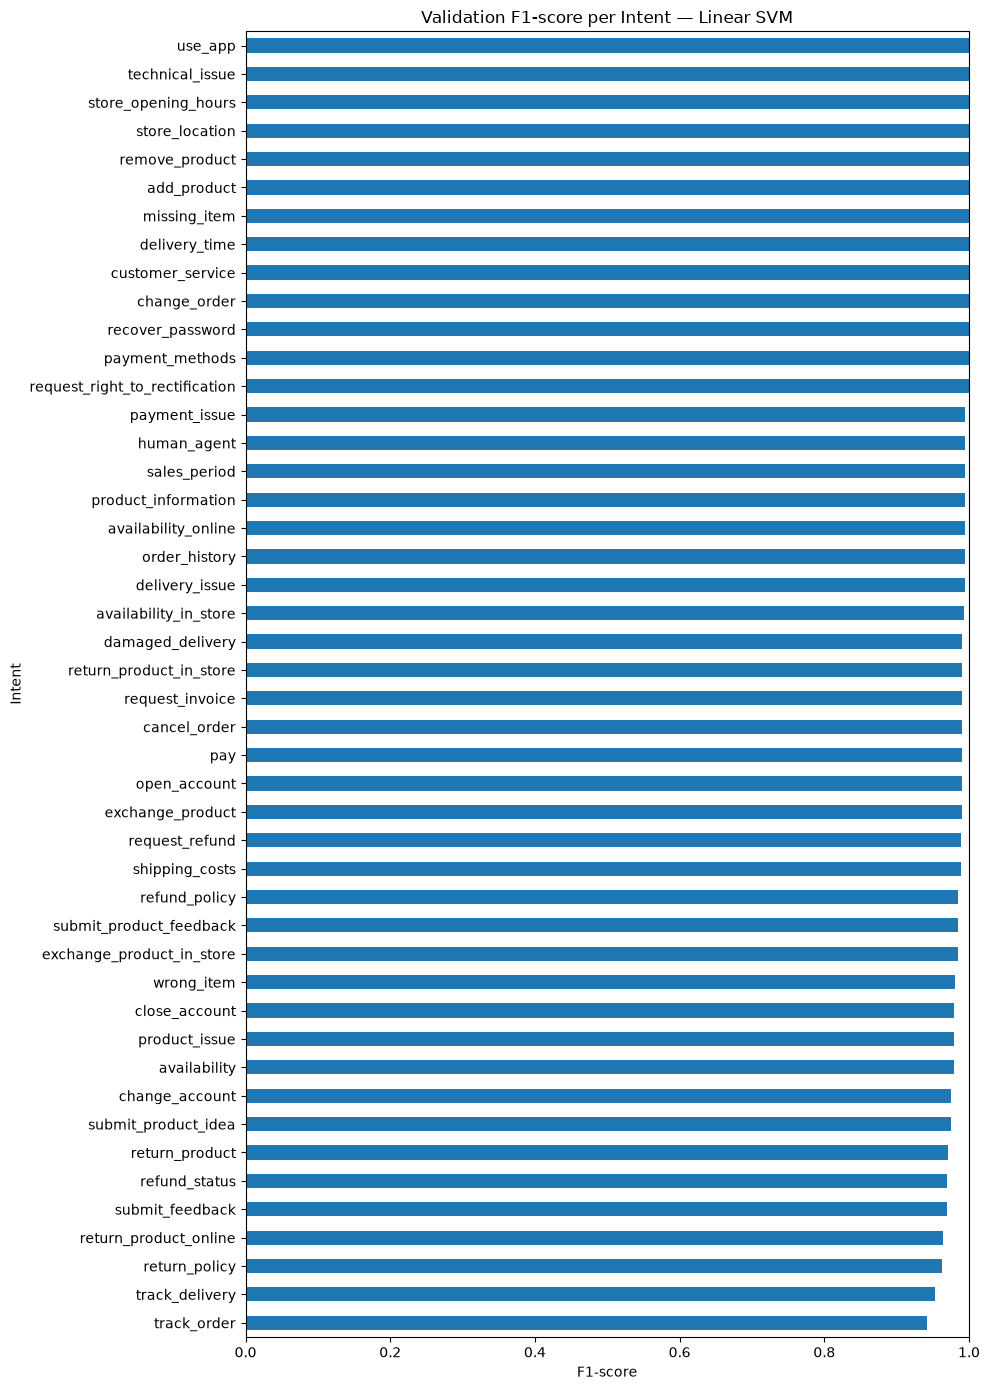

In [17]:
# visualisasi F1
(
    intent_report["f1-score"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(10, 14),
    )
)

plt.title(
    "Validation F1-score per Intent — Linear SVM"
)

plt.xlabel(
    "F1-score"
)

plt.ylabel(
    "Intent"
)

plt.xlim(
    0,
    1,
)

plt.tight_layout()

plt.show()

In [18]:
# error analysis
validation_results = (
    validation_df[
        [
            "instruction",
            "intent",
            "category",
        ]
    ]
    .copy()
)

validation_results[
    "predicted_intent"
] = validation_predictions

validation_results[
    "is_correct"
] = (
    validation_results["intent"]
    == validation_results[
        "predicted_intent"
    ]
)


In [19]:
errors = (
    validation_results[
        ~validation_results[
            "is_correct"
        ]
    ]
)

correct_count = (
    validation_results[
        "is_correct"
    ].sum()
)

print(
    f"Prediksi benar : "
    f"{correct_count:,}"
)

print(
    f"Prediksi salah : "
    f"{len(errors):,}"
)

print(
    f"Error rate     : "
    f"{len(errors) / len(validation_results):.2%}"
)

Prediksi benar : 4,426
Prediksi salah : 57
Error rate     : 1.27%


In [20]:
# lihar error
errors[
    [
        "instruction",
        "intent",
        "predicted_intent",
    ]
].head(20)

,instruction,intent,predicted_intent
22,need to report fuckingdelivery issues help me,delivery_issue,product_issue
34,could I retirn some fucking products in store?,return_policy,availability_in_store
108,im trying to find my fucking order historh i n...,order_history,track_order
196,i have to submit a fucking commenthelp me,submit_feedback,submit_product_idea
232,"I ogt to see where my shipment is, how can I d...",track_order,track_delivery
284,i got to report a defectiveproduct i purchased...,product_issue,damaged_delivery
368,id like to registre how can i do it,open_account,pay
520,how can I see where my package is?,track_order,track_delivery
533,i got to track my fucking erfund help me,refund_status,track_delivery
552,how could i rturn a fucking item online,return_policy,return_product_online


In [21]:
# confusion pair
labels = sorted(
    y_validation.unique()
)

cm = confusion_matrix(
    y_validation,
    validation_predictions,
    labels=labels,
)

confusion_pairs = []

for true_index, true_label in enumerate(
    labels
):
    for pred_index, predicted_label in enumerate(
        labels
    ):
        if true_label == predicted_label:
            continue

        count = cm[
            true_index,
            pred_index,
        ]

        if count > 0:
            confusion_pairs.append(
                {
                    "actual_intent": true_label,
                    "predicted_intent": predicted_label,
                    "count": int(count),
                }
            )

In [22]:
confusion_df = (
    pd.DataFrame(
        confusion_pairs
    )
    .sort_values(
        "count",
        ascending=False,
    )
)

confusion_df.head(15)

,actual_intent,predicted_intent,count
31,track_order,track_delivery,7
22,return_product_online,return_product,4
20,return_policy,return_product_online,3
5,close_account,change_account,3
16,refund_status,track_delivery,3
30,track_order,refund_status,3
19,return_policy,refund_policy,3
17,request_invoice,request_refund,2
9,exchange_product_in_store,return_product_in_store,2
26,submit_feedback,submit_product_idea,2


In [23]:
# decision margin
decision_scores = (
    model.decision_function(
        X_validation
    )
)

decision_scores.shape

(4483, 46)

In [24]:
# ambil score terbaik dan kedua
sorted_scores = np.sort(
    decision_scores,
    axis=1,
)

top_score = (
    sorted_scores[:, -1]
)

second_score = (
    sorted_scores[:, -2]
)

decision_margin = (
    top_score
    - second_score
)

In [25]:
validation_results[
    "decision_score"
] = top_score

validation_results[
    "decision_margin"
] = decision_margin

In [26]:
# lihat statistik
validation_results[
    [
        "decision_score",
        "decision_margin",
    ]
].describe()

,decision_score,decision_margin
count,4483.000000,4483.000000
mean,1.282146,2.225421
std,0.462345,0.568284
min,-0.738186,0.001918
25%,1.011531,1.945282
50%,1.330695,2.319577
75%,1.603716,2.611019
max,2.863467,3.741364


In [28]:
# error dengan margin terbesar
high_margin_errors = (
    validation_results[
        ~validation_results[
            "is_correct"
        ]
    ]
    .sort_values(
        "decision_margin",
        ascending=False,
    )
)

high_margin_errors[
    [
        "instruction",
        "intent",
        "predicted_intent",
        "decision_score",
        "decision_margin",
    ]
].head(15)

,instruction,intent,predicted_intent,decision_score,decision_margin
3435,need to see where my package is will ya help me,track_order,track_delivery,0.980109,1.973451
3631,"I want to see were my shipment is, how can I d...",track_order,track_delivery,0.945498,1.971323
520,how can I see where my package is?,track_order,track_delivery,0.837991,1.601705
3191,id like to return an order onloine where could...,return_product_online,return_product,0.883019,1.436411
3535,i have to see the availability of an item onoi...,availability_online,availability,0.730864,1.333780
232,"I ogt to see where my shipment is, how can I d...",track_order,track_delivery,0.424781,1.065473
1409,"I have to clsoe my profile, how to do it?",close_account,change_account,0.377758,1.036941
2017,can i return a fucking prduct online,return_policy,return_product_online,0.374580,0.885423
833,how to return a fucking item online,return_policy,return_product_online,0.511550,0.881689
4310,is it possible to see where my shipment is ?,track_order,track_delivery,0.288448,0.842343


In [30]:
# top features SVM
tfidf_model = (
    model.named_steps["tfidf"]
)

classifier_model = (
    model.named_steps[
        "classifier"
    ]
)

feature_names = (
    tfidf_model
    .get_feature_names_out()
)

In [31]:
# buat function
def show_top_features(
    intent,
    top_n=15,
):
    class_index = list(
        classifier_model.classes_
    ).index(intent)

    coefficients = (
        classifier_model
        .coef_[class_index]
    )

    top_indices = (
        np.argsort(
            coefficients
        )[-top_n:]
        [::-1]
    )

    return pd.DataFrame(
        {
            "feature": (
                feature_names[
                    top_indices
                ]
            ),
            "weight": (
                coefficients[
                    top_indices
                ]
            ),
        }
    )

In [32]:
show_top_features(
    "track_order",
    top_n=15,
)

,feature,weight
0,replacement,3.749391
1,my exchange,3.163192
2,order,2.628377
3,my replacement,2.579513
4,order is,2.236067
5,exchange,1.777774
6,product,1.565580
7,status,1.477851
8,fucking exchange,1.465979
9,my fucking,1.445258


In [33]:
show_top_features(
    "cancel_order",
    top_n=15,
)

,feature,weight
0,cancel,3.661793
1,canceling,2.044966
2,placed,1.735791
3,cancelling,1.615338
4,order,1.572896
5,to cancel,1.452847
6,cancel fucking,1.390420
7,cacnel,1.317750
8,cancel the,1.232629
9,canceping,1.228511


In [34]:
show_top_features(
    "payment_issue",
    top_n=15,
)

,feature,weight
0,payment,2.368142
1,payment issue,1.595387
2,payment issues,1.582070
3,problem,1.548544
4,problem paying,1.526998
5,payment problems,1.513419
6,payment problem,1.410297
7,solve,1.370239
8,notify,1.341901
9,to solve,1.290117


In [35]:
# simpan metrics
metrics = {
    "model": (
        "TF-IDF + Linear SVM"
    ),
    "validation_records": int(
        len(validation_df)
    ),
    "accuracy": float(
        accuracy
    ),
    "macro_precision": float(
        macro_precision
    ),
    "macro_recall": float(
        macro_recall
    ),
    "macro_f1": float(
        macro_f1
    ),
    "weighted_f1": float(
        weighted_f1
    ),
    "training_time_seconds": float(
        training_time
    ),
    "inference_time_seconds": float(
        inference_time
    ),
    "average_inference_ms": float(
        average_inference_ms
    ),
    "vocabulary_size": int(
        vocabulary_size
    ),
}

In [36]:
# simpan
METRICS_PATH = (
    REPORT_DIR
    / "linear_svm_validation_metrics.json"
)

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics,
        file,
        indent=4,
    )

print(
    f"Metrics disimpan ke:\n"
    f"{METRICS_PATH}"
)

Metrics disimpan ke:
..\reports\metrics\linear_svm_validation_metrics.json


In [37]:
# simpan model
MODEL_PATH = (
    MODEL_DIR
    / "tfidf_linear_svm.joblib"
)

joblib.dump(
    model,
    MODEL_PATH,
)

print(
    f"Model disimpan ke:\n"
    f"{MODEL_PATH}"
)

Model disimpan ke:
..\models\tfidf_linear_svm.joblib


In [38]:
# smoke test
loaded_model = joblib.load(
    MODEL_PATH
)

sample_questions = [
    "where is my order",
    "I want to cancel my order",
    "my payment is not working",
    "I need to return my product",
]

sample_predictions = (
    loaded_model.predict(
        sample_questions
    )
)

pd.DataFrame(
    {
        "question": sample_questions,
        "predicted_intent": (
            sample_predictions
        ),
    }
)

,question,predicted_intent
0,where is my order,track_order
1,I want to cancel my order,close_account
2,my payment is not working,missing_item
3,I need to return my product,return_product


In [39]:
# comparison logistic regression vs linear SVM
LOGISTIC_METRICS_PATH = (
    REPORT_DIR
    / "logistic_regression_validation_metrics.json"
)

with open(
    LOGISTIC_METRICS_PATH,
    "r",
    encoding="utf-8",
) as file:
    logistic_metrics = json.load(
        file
    )

In [40]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": (
                logistic_metrics[
                    "accuracy"
                ]
            ),
            "macro_f1": (
                logistic_metrics[
                    "macro_f1"
                ]
            ),
            "training_time": (
                logistic_metrics[
                    "training_time_seconds"
                ]
            ),
            "inference_ms": (
                logistic_metrics[
                    "average_inference_ms"
                ]
            ),
        },
        {
            "model": "Linear SVM",
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "training_time": (
                training_time
            ),
            "inference_ms": (
                average_inference_ms
            ),
        },
    ]
)

comparison_df

,model,accuracy,macro_f1,training_time,inference_ms
0,Logistic Regression,0.982378,0.982562,3.785486,0.014273
1,Linear SVM,0.987285,0.987429,12.267938,0.052467


## Kesimpulan Model Linear SVM

Model kedua menggunakan pendekatan **TF-IDF + Linear SVM**
untuk melakukan multiclass Intent Classification terhadap 46 intent.

Konfigurasi TF-IDF dibuat sama dengan model Logistic Regression
agar perbandingan antar-model tetap adil.

Model dilatih menggunakan Training Set dan dievaluasi menggunakan
Validation Set. Test Set belum digunakan.

### Hasil Validation

- Accuracy: **98.73%**
- Macro Precision: **98.77%**
- Macro Recall: **98.75%**
- Macro F1-score: **98.74%**
- Weighted F1-score: **98.73%**
- Training Time: **12.27 detik**
- Total Validation Inference Time: **0.2352 detik**
- Average Inference Time: **0.0525 ms/sample**
- TF-IDF Vocabulary Size: **9,038 features**

### Perbandingan dengan Logistic Regression

Linear SVM menghasilkan performa validation yang lebih tinggi
dibandingkan Logistic Regression.

- Logistic Regression Macro F1: **98.26%**
- Linear SVM Macro F1: **98.74%**

Peningkatan Macro F1 sekitar **0.49 percentage point**.

Pada validation set, jumlah kesalahan berkurang dari sekitar
79 prediksi pada Logistic Regression menjadi sekitar 57 prediksi
pada Linear SVM.

### Error Analysis

Kesalahan prediksi masih banyak terjadi pada intent yang memiliki
semantic dan lexical overlap, terutama:

- `track_order` dan `track_delivery`
- `return_product_online` dan `return_product`
- `return_policy` dan intent terkait return/refund
- `submit_feedback` dan `submit_product_idea`
- intent terkait account

Intent `track_order` tetap menjadi salah satu class tersulit,
menunjukkan bahwa sebagian kesalahan kemungkinan disebabkan oleh
kemiripan definisi intent dan pola bahasa pada dataset.

### Decision Margin

Linear SVM tidak menghasilkan probability secara native.

Decision function digunakan untuk menganalisis jarak keputusan
antar-class. Decision margin tidak dianggap sebagai probability
atau calibrated confidence.

Jika Linear SVM digunakan sebagai production classifier dan
probability dibutuhkan untuk mekanisme Human Escalation,
maka diperlukan tahap probability calibration.

### Interpretability

Analisis coefficient menunjukkan bahwa Linear SVM memanfaatkan
kata dan bigram yang relevan terhadap masing-masing intent.

Namun, beberapa feature dominan juga menunjukkan adanya kemungkinan
template pattern pada synthetic dataset. Oleh karena itu, validation
score yang tinggi perlu diinterpretasikan bersama dengan keterbatasan
dataset.

### Kesimpulan Sementara

Linear SVM menjadi model dengan predictive performance terbaik
sejauh ini, tetapi belum dipilih sebagai model final.

Model berikutnya yang akan dibandingkan adalah Transformer-based
Intent Classification menggunakan DistilBERT.